In [1]:
import os
import sys

# Get project root folder (one level above notebooks)
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
print("Project root:", project_root)

# Add src folder to sys.path so Python can find modules
sys.path.append(os.path.join(project_root, "src"))

# Define absolute paths for data folders and files
frames_dir = os.path.join(project_root, "data", "processed_frames")
raw_videos_dir = os.path.join(project_root, "data", "raw_videos")
features_csv = os.path.join(project_root, "data", "features.csv")

print("Frames directory:", frames_dir)
print("Raw videos directory:", raw_videos_dir)
print("Features CSV path:", features_csv)

Project root: /Users/josebabermejo/Ironhack/silent_scream_detector
Frames directory: /Users/josebabermejo/Ironhack/silent_scream_detector/data/processed_frames
Raw videos directory: /Users/josebabermejo/Ironhack/silent_scream_detector/data/raw_videos
Features CSV path: /Users/josebabermejo/Ironhack/silent_scream_detector/data/features.csv


In [3]:
# Now you can import your functions
from data_preprocessing.extract_frames import extract_frames
from feature_extraction.extract_features import extract_features_from_frames

In [103]:
# Example: capture frames from webcam to correct folder
extract_frames(source="webcam", output_dir=frames_dir, frame_interval=10)

[INFO] Press 'q' to stop webcam capture.
[INFO] Saved 40 frames to /Users/josebabermejo/Ironhack/silent_scream_detector/data/processed_frames


In [105]:
extract_features_from_frames(
    frame_dir="/Users/josebabermejo/Ironhack/silent_scream_detector/data/processed_frames", 
    output_csv="/Users/josebabermejo/Ironhack/silent_scream_detector/data/features_calm4.csv"
)

I0000 00:00:1748963894.323401  717827 gl_context.cc:369] GL version: 2.1 (2.1 Metal - 89.4), renderer: Apple M3
W0000 00:00:1748963894.331107  826071 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
I0000 00:00:1748963894.336640  717827 gl_context.cc:369] GL version: 2.1 (2.1 Metal - 89.4), renderer: Apple M3
W0000 00:00:1748963894.337460  826071 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
  0%|                                                    | 0/55 [00:00<?, ?it/s]W0000 00:00:1748963894.400736  826079 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1748963894.409293  826086 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disablin

[INFO] Saved features to /Users/josebabermejo/Ironhack/silent_scream_detector/data/features_calm4.csv


## Testing 9 csv feature files to see if it's enough to train the model.

In [9]:
import pandas as pd

def data_path(filename):
    return os.path.join(project_root, "data", filename)

# Tuples of (filename, classification label)
csv_files = [
    ("features_calm.csv", 0),
    ("features_calm2.csv", 0),
    ("features_calm3.csv", 0),
    ("features_calm4.csv", 0),
    ("features_distress.csv", 1),
    ("features_distress2.csv", 1),
    ("features_distress3.csv", 1),
    ("features_distress4.csv", 1),
    ("features_distress5.csv", 1),
]

In [11]:
# Load, label, and collect dataframes
dfs = []
for filename, label in csv_files:
    df = pd.read_csv(data_path(filename))
    df["classification"] = label
    dfs.append(df)

# Combine them all
combined_df = pd.concat(dfs, ignore_index=True)

In [13]:
combined_df

,filename,eye_openness,mouth_openness,shoulder_tilt,hand_face_dist,classification
0,00000.jpg,0.022348,0.000715,0.032976,1.218871,0
1,00001.jpg,0.023951,0.002164,0.052460,1.232344,0
2,00002.jpg,0.024519,0.001235,0.044382,1.277656,0
3,00003.jpg,0.029110,0.002011,0.032402,1.313677,0
4,00004.jpg,0.029086,0.002568,0.056588,1.270468,0
...,...,...,...,...,...,...
490,00050.jpg,0.026680,0.008098,0.053988,1.255346,1
491,00051.jpg,0.026861,0.006631,0.011841,1.203924,1
492,00052.jpg,0.024348,0.010042,0.013918,1.144536,1
493,00053.jpg,0.021527,0.008046,0.030641,1.156000,1


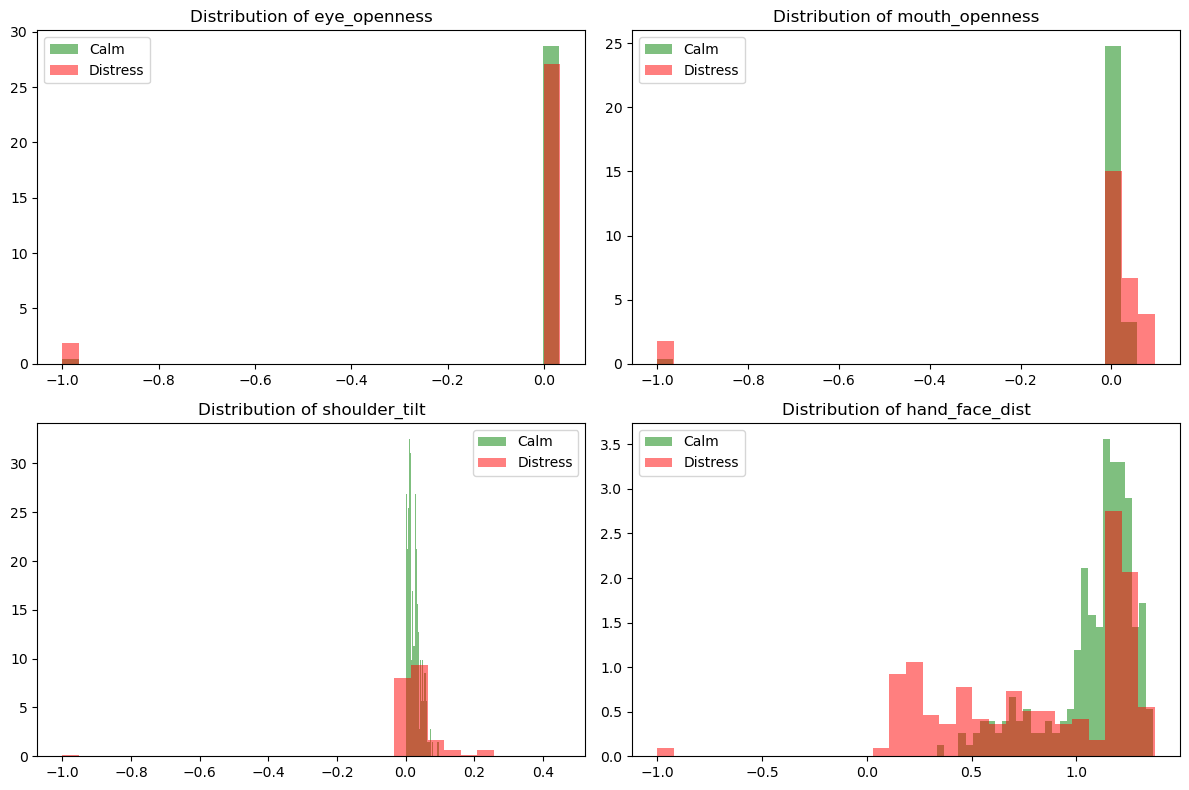

In [17]:
# Plot some feature distributions by label
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

features_to_plot = ["eye_openness", "mouth_openness", "shoulder_tilt", "hand_face_dist"]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, feature in enumerate(features_to_plot):
    for label, color, name in zip([0, 1], ['green', 'red'], ['Calm', 'Distress']):
        subset = combined_df[combined_df["classification"] == label]
        axes[i].hist(subset[feature], bins=30, alpha=0.5, label=name, color=color, density=True)
    axes[i].set_title(f"Distribution of {feature}")
    axes[i].legend()

plt.tight_layout()
plt.show()

## Now I can train the first iteration of the model

In [19]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve

# 1. Sanity check class balance
combined_df["classification"].value_counts()

classification
1    275
0    220
Name: count, dtype: int64

In [21]:
# 2. Prepare features and labels
X = combined_df.drop(columns=["filename", "classification"])
y = combined_df["classification"]

# 3. Split into train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

In [23]:
# 4. Train Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [25]:
# 5. Evaluate
y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:, 1]

print("[INFO] Accuracy:", accuracy_score(y_test, y_pred))
print("[INFO] Classification Report:\n", classification_report(y_test, y_pred))

[INFO] Accuracy: 0.7516778523489933
[INFO] Classification Report:
               precision    recall  f1-score   support

           0       0.77      0.62      0.69        66
           1       0.74      0.86      0.79        83

    accuracy                           0.75       149
   macro avg       0.76      0.74      0.74       149
weighted avg       0.75      0.75      0.75       149



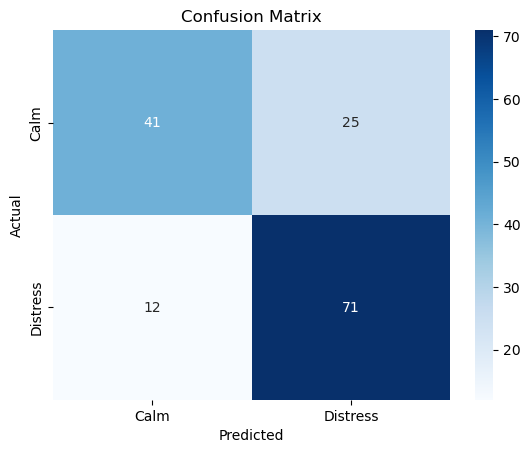

In [27]:
# 6. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Calm", "Distress"], yticklabels=["Calm", "Distress"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()